In [1]:
# Cell 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Cell 2: Quick data check
print(df.isnull().sum())
print("\n", df.describe())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.0

In [3]:
# Cell 3: Split features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


In [4]:
# Cell 4: Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Intercept:", model.intercept_)

Model trained successfully!
Intercept: -37.02327770606409


In [5]:
# Cell 5: Interpret model coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


In [6]:
# Cell 6: Evaluate model performance
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 0.5559
R-squared: 0.5758


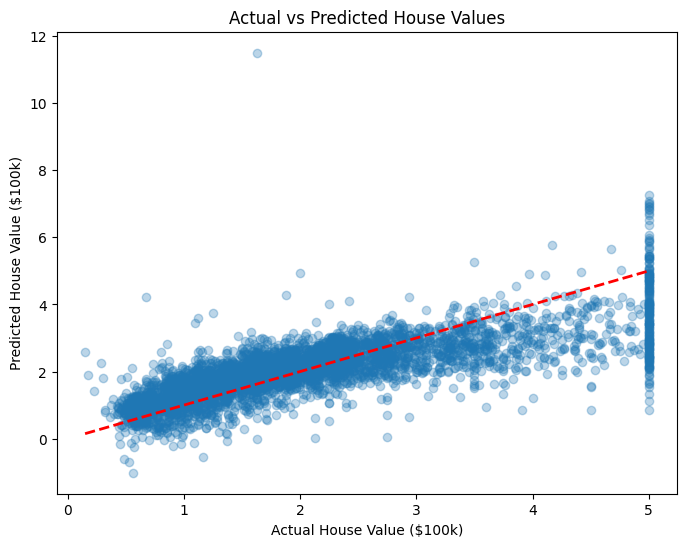

In [7]:
# Cell 7: Visualize predictions vs actual values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual House Value ($100k)")
plt.ylabel("Predicted House Value ($100k)")
plt.title("Actual vs Predicted House Values")
plt.show()

In [8]:
# Cell 8: Summary
print("="*50)
print("TASK 2 SUMMARY: Simple Linear Regression")
print("="*50)
print(f"Dataset: California Housing ({df.shape[0]} samples, {df.shape[1]-1} features)")
print(f"Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}")
print(f"R-squared: {r2:.4f} (model explains ~{r2*100:.1f}% of variance)")
print(f"MSE: {mse:.4f} | RMSE: ${(mse**0.5)*100000:,.0f}")
print(f"Strongest positive predictor: MedInc (median income)")
print(f"Note: Model underperforms at high price ranges, partly due to")
print(f"the dataset's $500k value cap and non-linear pricing dynamics.")

TASK 2 SUMMARY: Simple Linear Regression
Dataset: California Housing (20640 samples, 8 features)
Train set: 16512 | Test set: 4128
R-squared: 0.5758 (model explains ~57.6% of variance)
MSE: 0.5559 | RMSE: $74,558
Strongest positive predictor: MedInc (median income)
Note: Model underperforms at high price ranges, partly due to
the dataset's $500k value cap and non-linear pricing dynamics.
